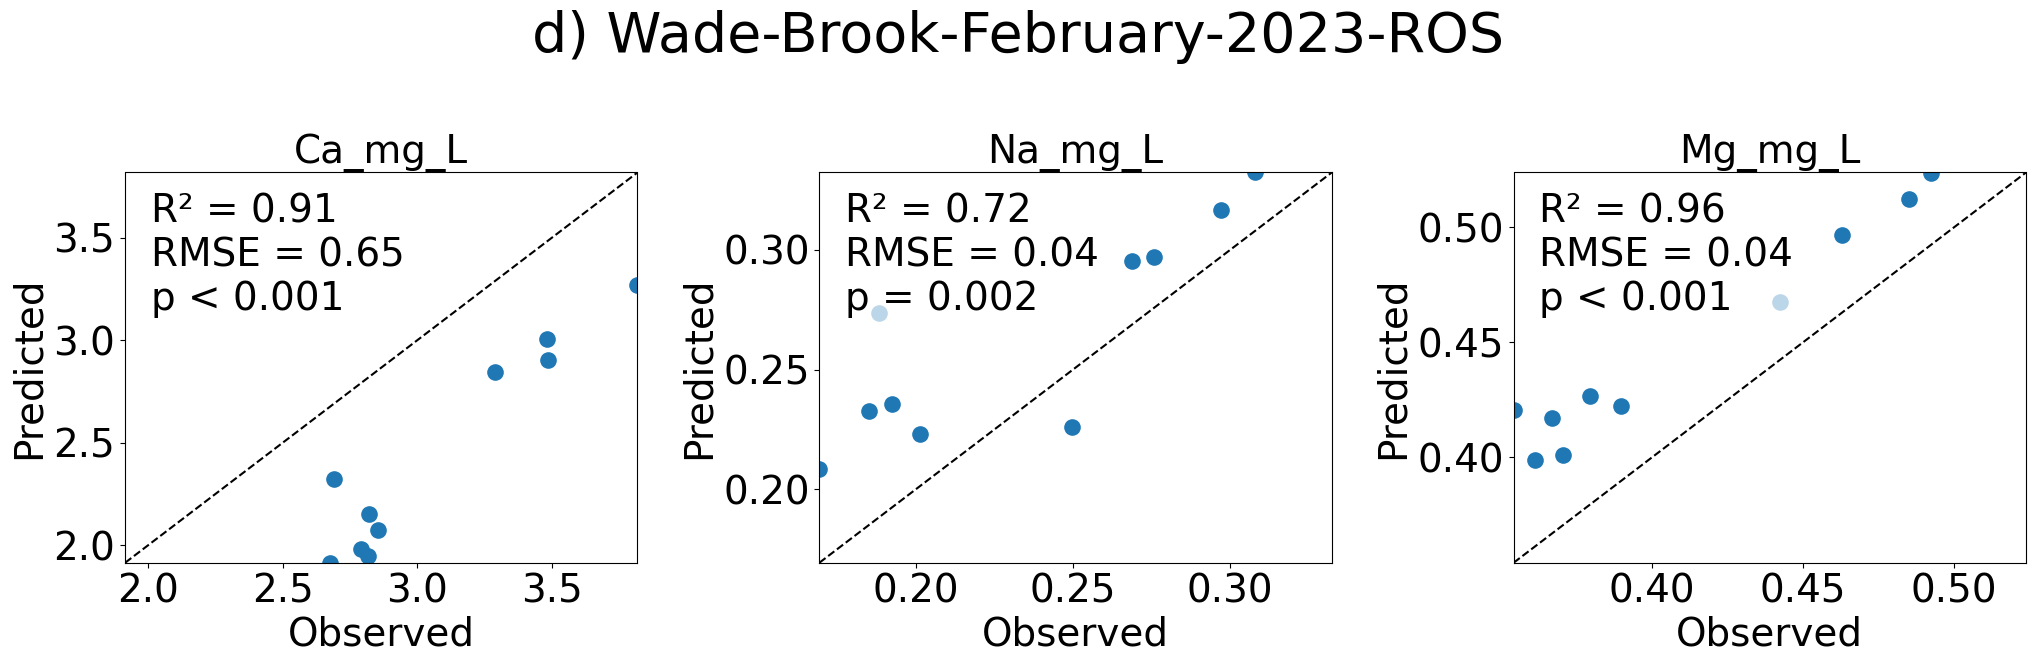

✅ Figure saved to output dir


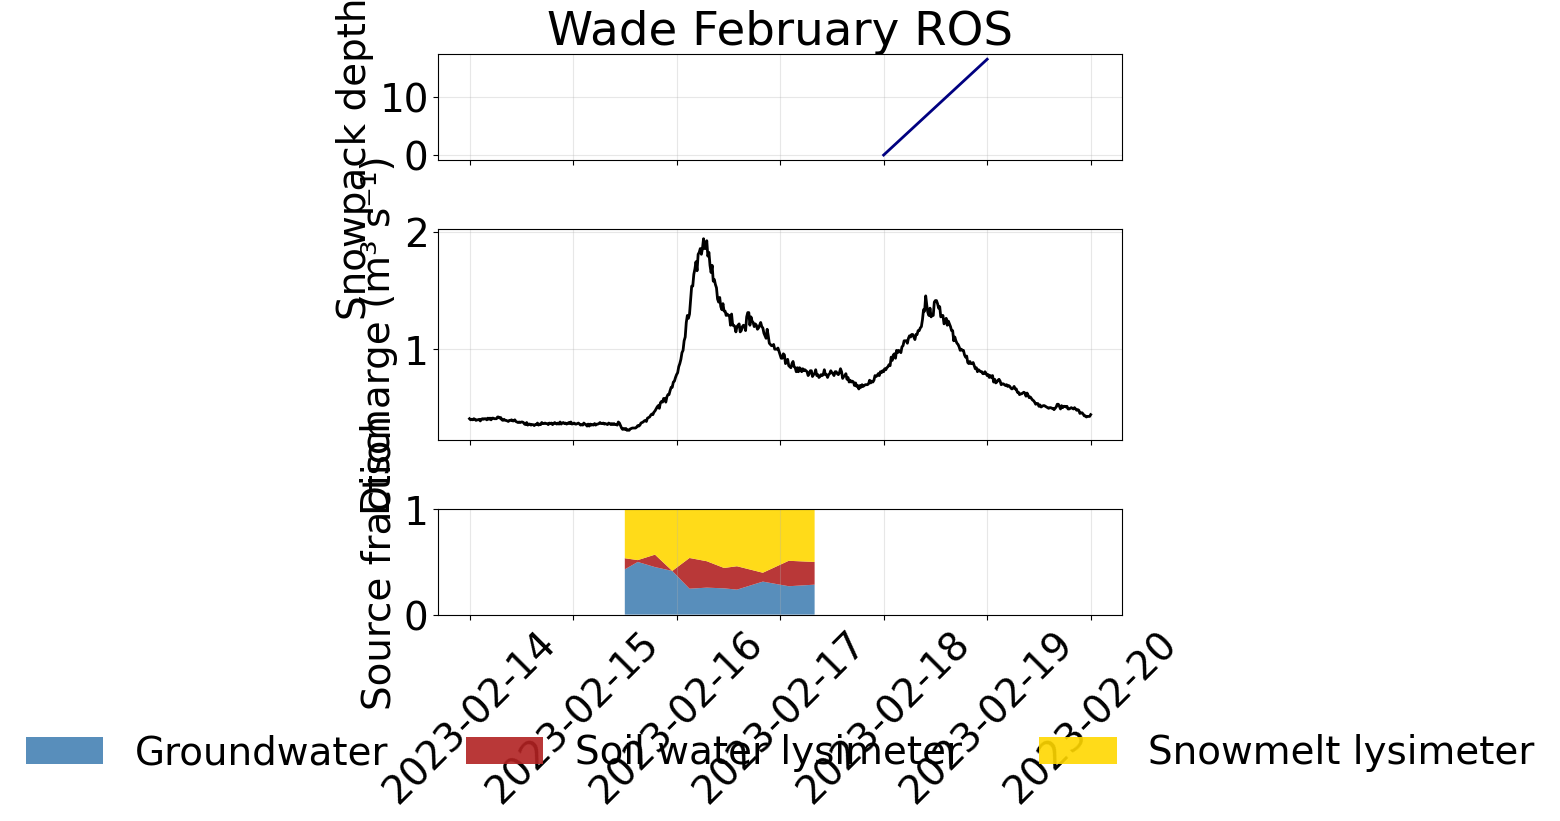

Saved fractions to EMMA-results


,Sample ID,Datetime,Site,Groundwater,Snowmelt lysimeter,Soil water lysimeter,Sum_Fractions
0,RI23-1009,2023-02-15 15:00:00,Wade,0.499577,0.482952,1.747075e-02,1.0
1,RI23-1010,2023-02-15 19:00:00,Wade,0.450879,0.431147,1.179747e-01,1.0
2,RI23-1011,2023-02-15 23:00:00,Wade,0.414333,0.585667,1.131854e-15,1.0
3,RI23-1025,2023-02-15 12:00:00,Wade,0.429392,0.465132,1.054759e-01,1.0
4,RI23-1012,2023-02-16 03:00:00,Wade,0.245741,0.462826,2.914328e-01,1.0


In [10]:
import importlib
import sys
from pathlib import Path
import pandas as pd

# Set up home path and working repo dir 
HOME = Path.home()
repo_dir = HOME / "OneDrive/git-repos/LCBP-interannual-EMMAs"

if str(repo_dir) not in sys.path:
    sys.path.append(str(repo_dir))

# Import EMMA module
import EMMA.event_emma as em  
import EMMA.event_pca_error as ep
importlib.reload(ep)
importlib.reload(em)

# Define data directory using relative path logic
data_dir = repo_dir / "Data"

output_dir = repo_dir / "Output/EMMA-results/" 

# Load the full RI23 dataset
df = pd.read_csv(data_dir / "GrabSample_data/RI23-IC-ICP-isotope-toc-joined.csv")

#################
# FEB ROS at WB #
#################

# Event A
# Wade February ROS event
# Endmembers: 
    # RI23-5018 Groundwater Bear Pond 03/10/23
    # RI23-5006 Groundwater High Pond 03/01/23 (could be 03/10/23, doesn't really matter)
    # RI23-5000 Soil water lysimeter dry 02/15/23
    # RI23-5005 Snowmelt lysimeter 2/15
    # RI23-1034 Pre-event baseflow, labeled as GW in Wade index

    # Adding in RI22 and RI25 groundwater samples to try and reduce uncertainty
        # RIRI22-0860 Bear Pond GW
        # RI22-0859 High Pond GW
        # RI25-1111 Baseflow
        # RI25-1126 Baseflow
        # RI25-1183 Baseflow
        # RI25-1201 Baseflow
        # RI25-1290 Basedlow

wade_febros_fractions_df, wade_febros_scaler, wade_febros_pca, wade_febros_endmembers_df = em.run_emma_event(
    data=df,
    site="Wade",
    start_date="2023-02-14 00:00:00",
    end_date="2023-02-20 00:00:00",
    endmember_ids=[
                   "RI23-5018", #"RI23-5006", # Homeowner well groundwater March 2023
                   #"RI22-0860", "RI22-0859", # Homeowner well groundwater 2022
                   #"RI23-1034", # Pre-event baseflow, labeled as GW in Wade index
                   #"RI25-1111", "RI25-1126", "RI25-1183", "RI25-1201", "RI25-1290", # 2025 baseflow samples        
                   "RI23-5000", # SWL D February 15 2023
                   "RI23-5005", # Snowmelt lysimeter 2/15
                  ], 
)

#wade_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L'] # Original WRR submission tracers
wade_tracers = ['Ca_mg_L', 'Na_mg_L', 'Mg_mg_L'] # WRR resubmission tracers

# Call the prediction function
wade_febros_predicted = em.predict_tracers_from_fractions(
    fractions_df=wade_febros_fractions_df,
    endmembers_df=wade_febros_endmembers_df,
    tracer_cols=wade_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted(
    title = "d) Wade-Brook-February-2023-ROS", 
    predicted_df = wade_febros_predicted, 
    stream_df = df, 
    tracer_cols = wade_tracers,
    output_dir=output_dir)

# Plot EMMA fractions with hydrograph and snowpack depth

# Plot EMMA fractions with hydrograph and snowpack depth
wade_febros_plot = em.plot_emma_fractions_with_hydrograph(
    fractions_df      = wade_febros_fractions_df,
    discharge_csv     = data_dir / "StreamSensor_data/Discharge.Discharge_cms@Wade_Brook.20221001.csv",
    start_date        = "2023-02-14 00:00:00",
    end_date          = "2023-02-20 00:00:00",
    site              = "Wade",
    discharge_time_col= "Timestamp (UTC-04:00)",
    discharge_value_col="Value",
    snowpack_csv      = data_dir / "Met_data/Wade_cocorahs-vt-fr-30-20221115-20250414-2.csv",
    snowpack_time_col = "Date",
    snowpack_depth_col= "snowpack_cm",
    title             = "Wade February ROS"
)

# Save the EMMA fractions to EMMA-results directory

output_file_path = output_dir / "Wade_Feb_ROS_fractions.csv"
wade_febros_fractions_df.to_csv(output_file_path, index=False)

print(f"Saved fractions to EMMA-results")

wade_febros_fractions_df.head()

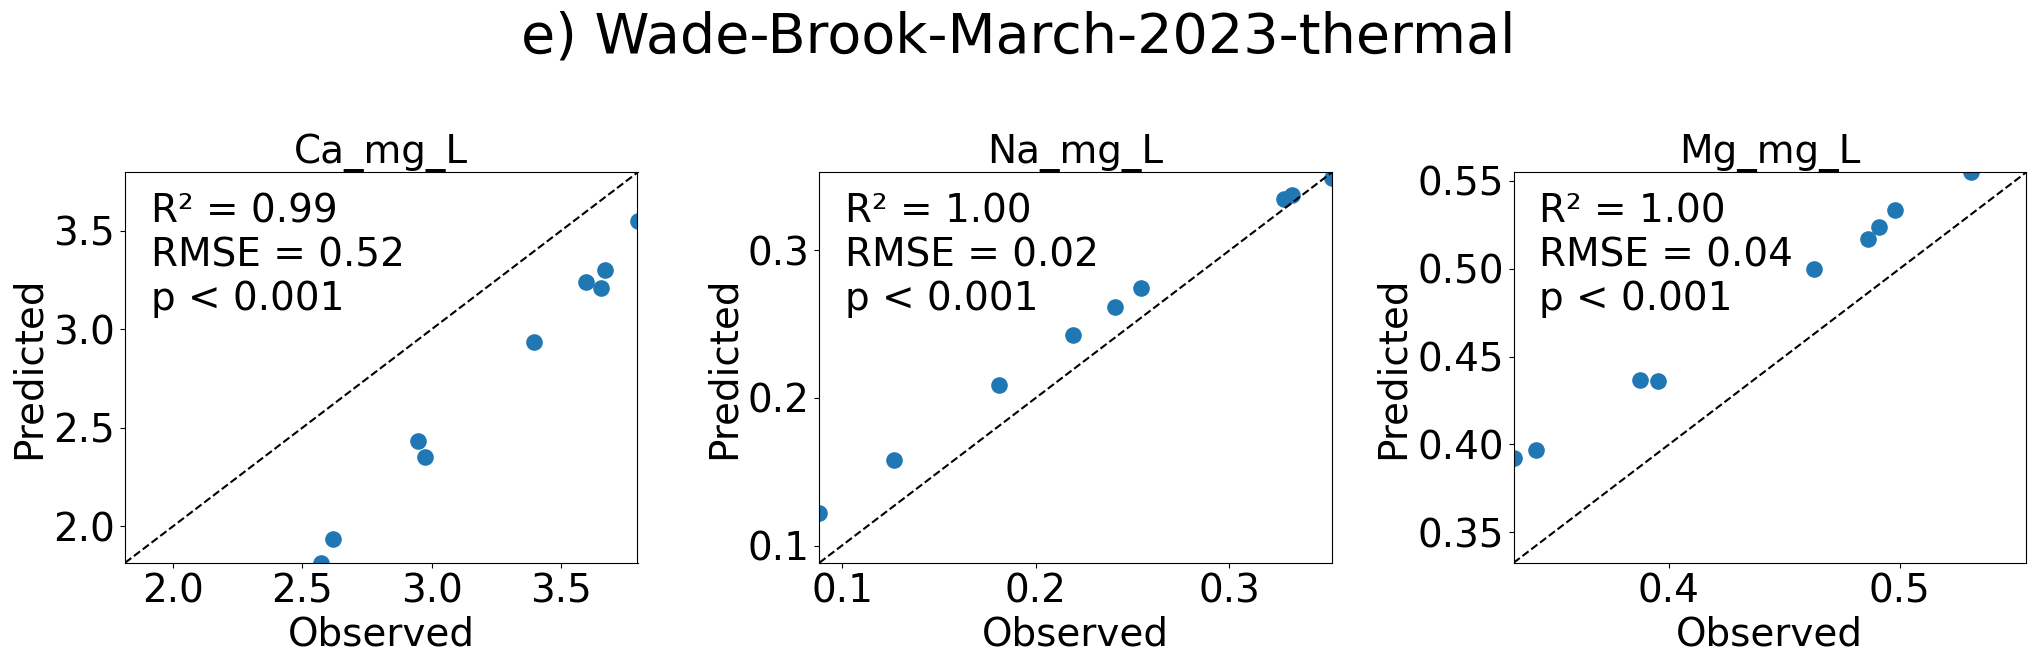

✅ Figure saved to output dir


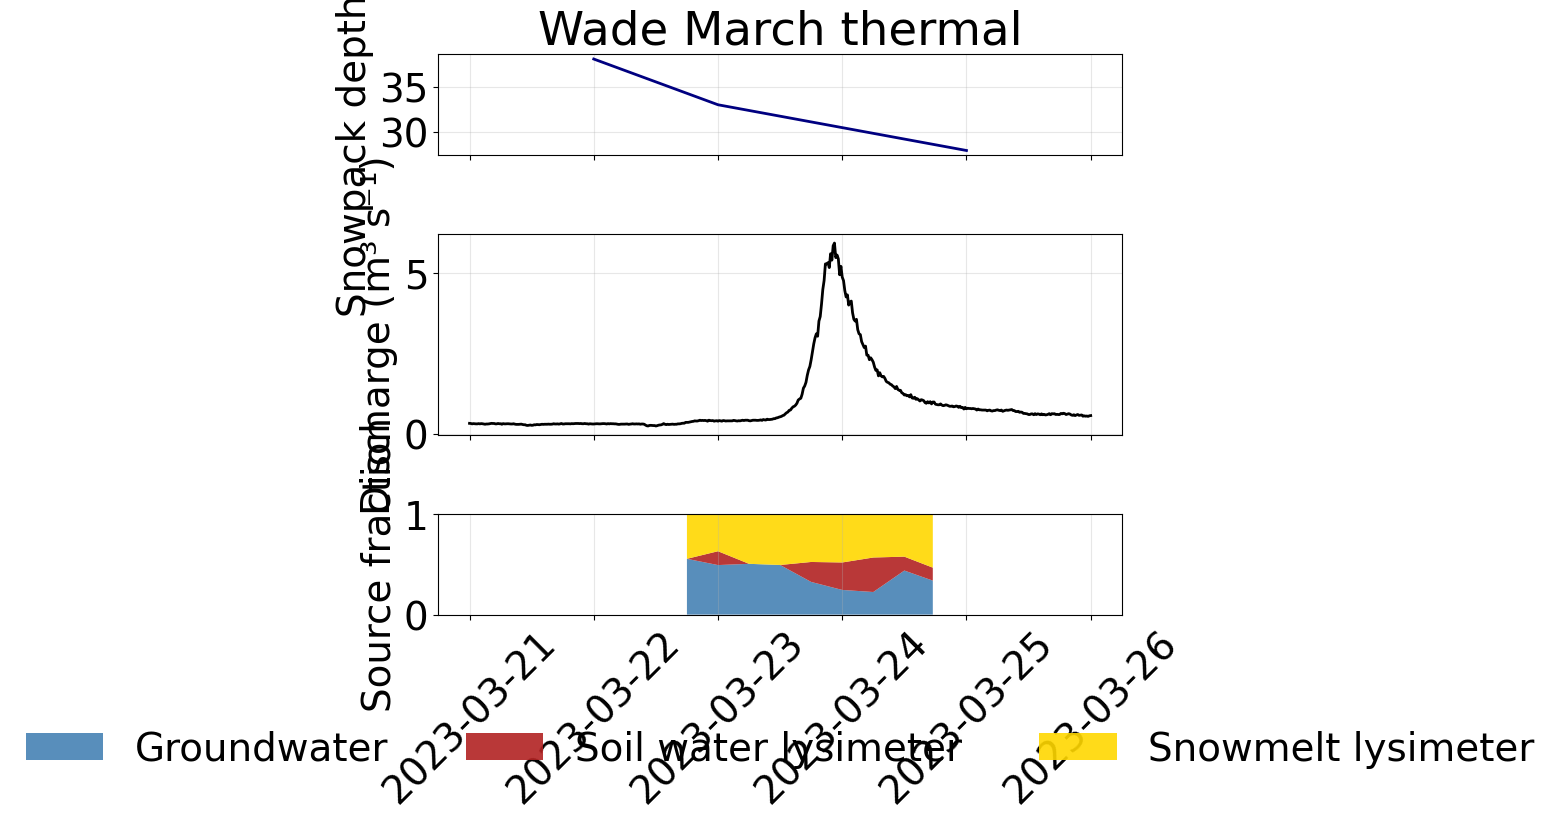

Saved fractions to EMMA-results


,Sample ID,Datetime,Site,Groundwater,Snowmelt lysimeter,Soil water lysimeter,Sum_Fractions
0,RI23-1039,2023-03-22 18:00:00,Wade,0.554301,0.445699,2.078197e-14,1.0
1,RI23-1040,2023-03-23 00:00:00,Wade,0.492368,0.370275,1.373570e-01,1.0
2,RI23-1041,2023-03-23 06:00:00,Wade,0.504608,0.495392,9.470066e-15,1.0
3,RI23-1055,2023-03-23 12:00:00,Wade,0.493162,0.506838,0.000000e+00,1.0
4,RI23-1056,2023-03-23 18:00:00,Wade,0.324627,0.476912,1.984611e-01,1.0


In [11]:
import importlib
import sys
from pathlib import Path
import pandas as pd

# Set up home path and working repo dir 
HOME = Path.home()
repo_dir = HOME / "OneDrive/git-repos/LCBP-interannual-EMMAs"

if str(repo_dir) not in sys.path:
    sys.path.append(str(repo_dir))

# Import EMMA module
import EMMA.event_emma as em  
import EMMA.event_pca_error as ep
importlib.reload(ep)
importlib.reload(em)

# Define data directory using relative path logic
data_dir = repo_dir / "Data"

output_dir = repo_dir / "Output/EMMA-results/" 

# Load the full RI23 dataset
df = pd.read_csv(data_dir / "GrabSample_data/RI23-IC-ICP-isotope-toc-joined.csv")

#################
# MAR THM at WB #
#################

# Event B
# Wade March 2023 thermal event
# Endmembers: 
    # RI23-5018 Groundwater Bear Pond 03/10/23
    # RI23-5006 Groundwater High Pond 03/01/23 (could be 03/10/23, doesn't really matter)
    # RI23-5000 Soil water lysimeter dry 02/15/23 (removed)
    # RI23-5005 Snowmelt lysimeter 2/15 (removed)
    # RI23-5009 Soil water lysimeter dry 3/16 (removed)
    # RI23-1063 Snowmelt lysimeter 3/28
    # RI23-1034 Baseflow 3/22 (labeled as GW)
    # RI23-5011 Soil water lysimeter wet 4/12

    # Adding in RI22 and RI25 groundwater samples to try and reduce uncertainty
        # RIRI22-0860 Bear Pond GW
        # RI22-0859 High Pond GW
        # RI25-1111 Baseflow
        # RI25-1126 Baseflow
        # RI25-1183 Baseflow
        # RI25-1201 Baseflow
        # RI25-1290 Basedlow

wade_martherm_fractions_df, wade_martherm_scaler, wade_martherm_pca, wade_martherm_endmembers_df = em.run_emma_event(
    data=df,
    site="Wade",
    start_date="2023-03-21 00:00:00",
    end_date="2023-03-26 00:00:00",
    endmember_ids=[
                   "RI23-5018", #"RI23-5006", # Homeowner well groundwater March 2023
                   #"RI22-0860", "RI22-0859", # Homeowner well groundwater 2022
                   #"RI23-1034", # Pre-event baseflow
                   #"RI25-1111", "RI25-1126", "RI25-1183", "RI25-1201", "RI25-1290", # 2025 baseflow samples 
                   "RI23-5005", # Snowmelt lysimeter 02/15/2023
                   #"RI23-1063", # Snowmelt lysimeter 3/28
                   #"RI23-1098", # Snowmelt lysimeter 04/11/2023
                   "RI23-5009", # Soil water lysimeter sample
                   #"RI23-5011", # Soil water lysimeter wet 4/12
                   ])

#wade_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L'] # Original WRR submission tracers
wade_tracers = ['Ca_mg_L', 'Na_mg_L', 'Mg_mg_L'] # WRR resubmission tracers

# Call the prediction function
wade_martherm_predicted = em.predict_tracers_from_fractions(
    fractions_df=wade_martherm_fractions_df,
    endmembers_df=wade_martherm_endmembers_df,
    tracer_cols=wade_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted(
    title = "e) Wade-Brook-March-2023-thermal", 
    predicted_df = wade_martherm_predicted, 
    stream_df = df, 
    tracer_cols = wade_tracers,
    output_dir=output_dir)

# Plot EMMA fractions with hydrograph and snowpack depth

# Plot EMMA fractions with hydrograph and snowpack depth
wade_martherm_plot = em.plot_emma_fractions_with_hydrograph(
    fractions_df      = wade_martherm_fractions_df,
    discharge_csv     = data_dir / "StreamSensor_data/Discharge.Discharge_cms@Wade_Brook.20221001.csv",
    start_date        = "2023-03-21 00:00:00",
    end_date          = "2023-03-26 00:00:00",
    site              = "Wade",
    discharge_time_col= "Timestamp (UTC-04:00)",
    discharge_value_col="Value",
    snowpack_csv      = data_dir / "Met_data/Wade_cocorahs-vt-fr-30-20221115-20250414-2.csv",
    snowpack_time_col = "Date",
    snowpack_depth_col= "snowpack_cm",
    title             = "Wade March thermal"
)

# Save the EMMA fractions to EMMA-results directory

output_file_path = output_dir / "Wade_Mar_therm_fractions.csv"
wade_martherm_fractions_df.to_csv(output_file_path, index=False)

print(f"Saved fractions to EMMA-results")

wade_martherm_fractions_df.head()

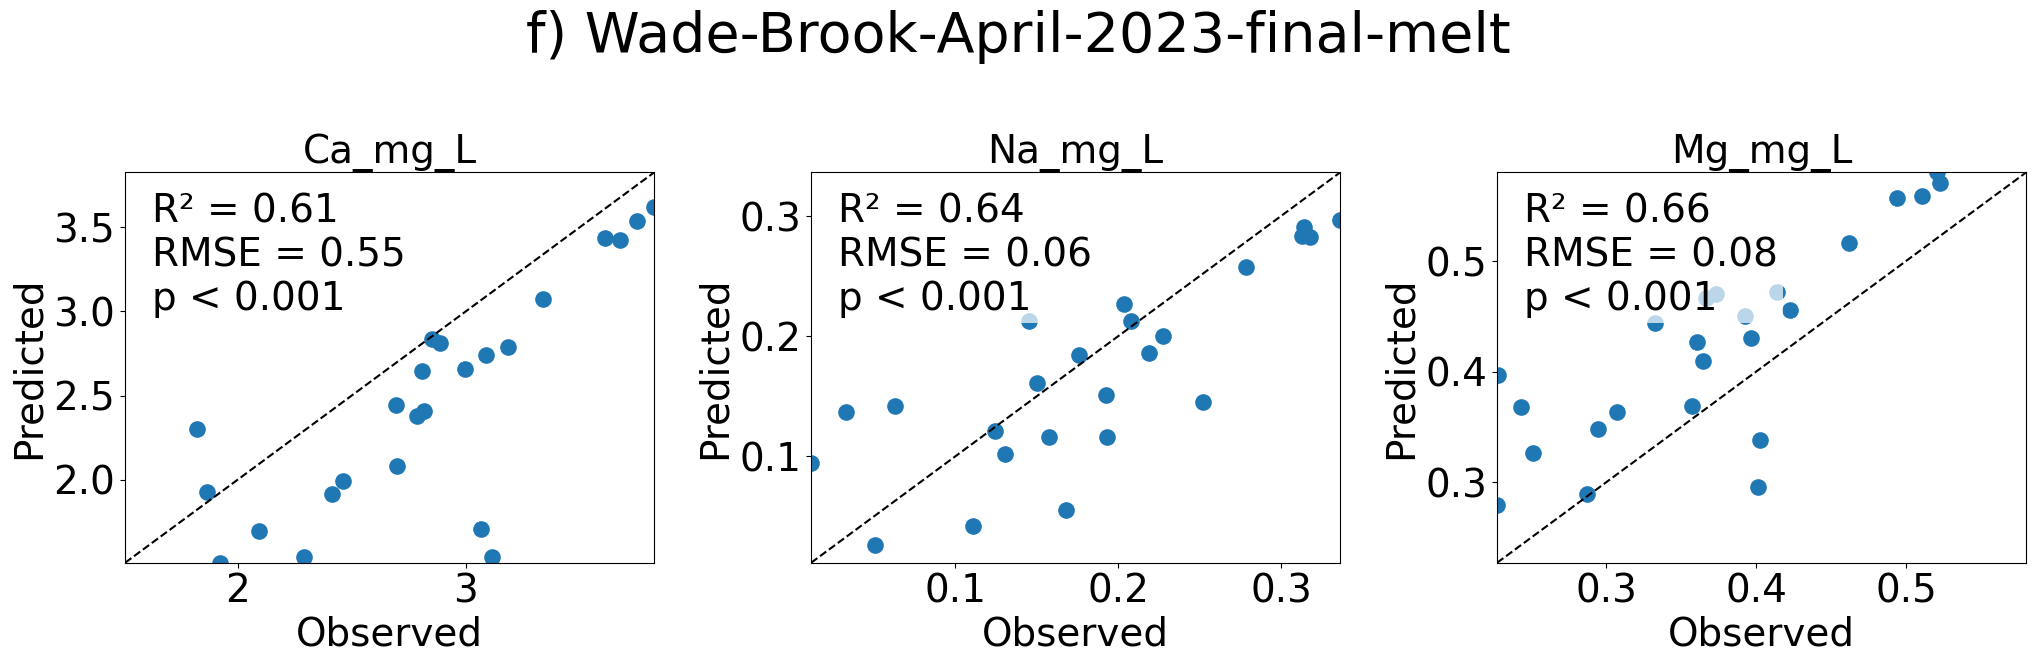

✅ Figure saved to output dir


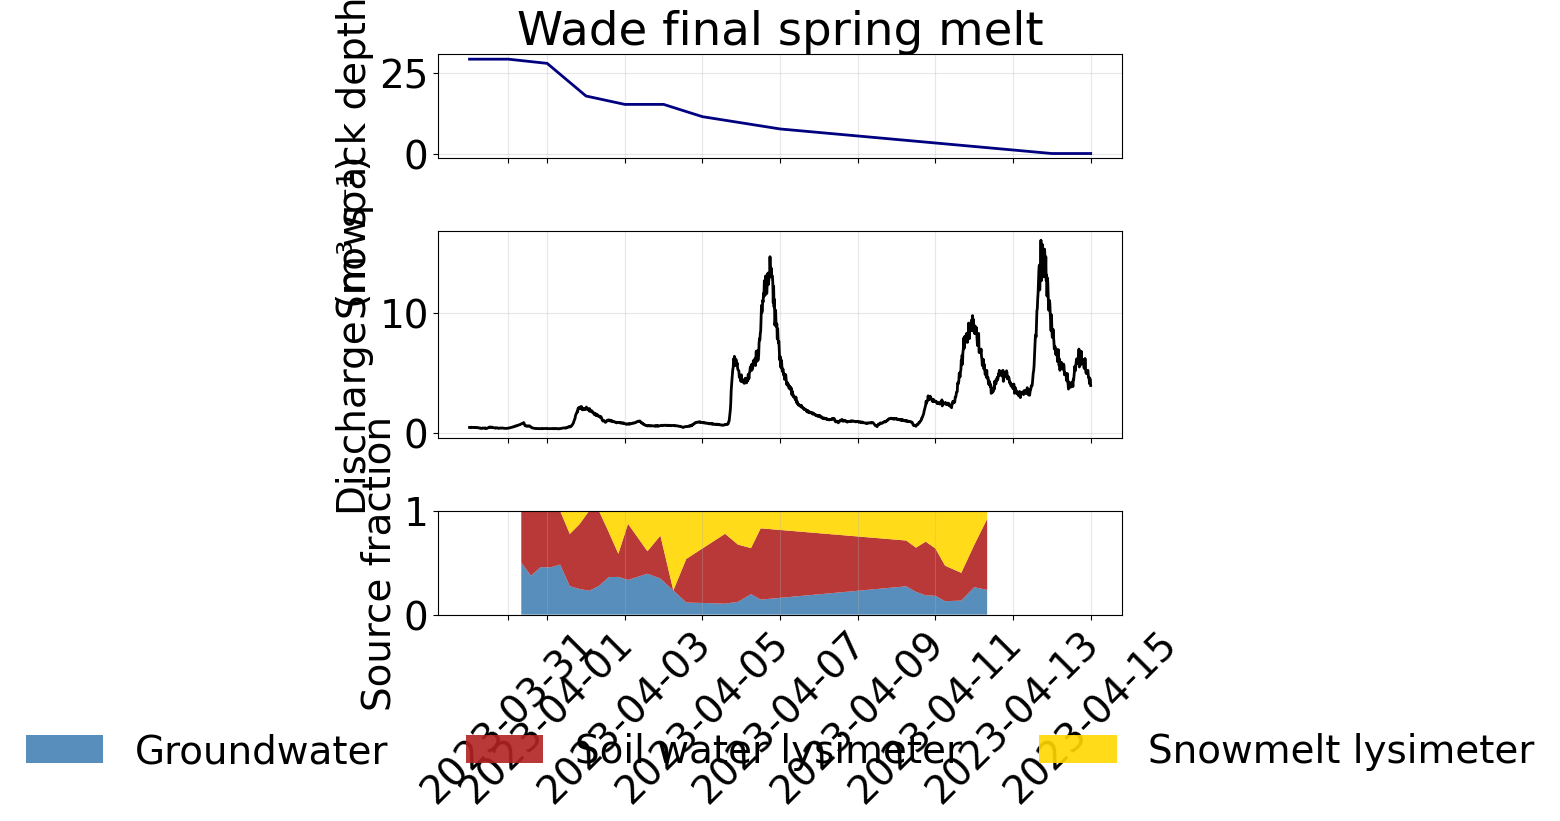

Saved fractions to EMMA-results


,Sample ID,Datetime,Site,Groundwater,Snowmelt lysimeter,Soil water lysimeter,Sum_Fractions
0,RI23-1064,2023-03-31 08:00:00,Wade,0.500580,0.000000e+00,0.499420,1.0
1,RI23-1065,2023-03-31 14:00:00,Wade,0.374702,8.000588e-16,0.625298,1.0
2,RI23-1066,2023-03-31 20:00:00,Wade,0.457860,0.000000e+00,0.542140,1.0
3,RI23-1067,2023-04-01 02:00:00,Wade,0.455074,2.768781e-15,0.544926,1.0
4,RI23-1068,2023-04-01 08:00:00,Wade,0.481835,1.067804e-16,0.518165,1.0


In [12]:
import importlib
import sys
from pathlib import Path
import pandas as pd

# Set up home path and working repo dir 
HOME = Path.home()
repo_dir = HOME / "OneDrive/git-repos/LCBP-interannual-EMMAs"

if str(repo_dir) not in sys.path:
    sys.path.append(str(repo_dir))

# Import EMMA module
import EMMA.event_emma as em  
import EMMA.event_pca_error as ep
importlib.reload(ep)
importlib.reload(em)

# Define data directory using relative path logic
data_dir = repo_dir / "Data"

output_dir = repo_dir / "Output/EMMA-results/" 

# Load the full RI23 dataset
df = pd.read_csv(data_dir / "GrabSample_data/RI23-IC-ICP-isotope-toc-joined.csv")

#################
# FRESHET at WB #
#################

# Event C
# Wade freshet
# Endmembers: 
    # RI23-5018 Groundwater Bear Pond 03/10/23
    # RI23-5006 Groundwater High Pond 03/01/23 (could be 03/10/23, doesn't really matter)
    # RI23-5010 Precip 04/10
    # RI23-1098 Snowmelt lysimeter 4/11
    # RI23-5011 Soil water lysimeter wet 4/12
    # RI23-5012 Snowmelt lysimeter 4/12
    # RI23-1063 Snowmelt lysimeter 3/28

    # Adding in RI22 and RI25 groundwater samples to try and reduce uncertainty
        # RIRI22-0860 Bear Pond GW
        # RI22-0859 High Pond GW
        # RI25-1111 Baseflow
        # RI25-1126 Baseflow
        # RI25-1183 Baseflow
        # RI25-1201 Baseflow
        # RI25-1290 Basedlow

wade_fmelt_fractions_df, wade_fmelt_scaler, wade_fmelt_pca, wade_fmelt_endmembers_df = em.run_emma_event(
    data=df,
    site="Wade",
    start_date="2023-03-30 00:00:00",
    end_date="2023-04-15 00:00:00",
    endmember_ids=[
                   "RI23-5018", #"RI23-5006", # Homeowner well groundwater March 2023
                   #"RI22-0860", "RI22-0859", # Homeowner well groundwater 2022
                   #"RI23-1034", # Pre-event baseflow, labeled as GW in Wade index
                   #"RI25-1111", "RI25-1126", "RI25-1183", "RI25-1201", "RI25-1290", # 2025 baseflow samples 
                   #"RI23-5005", # Snowmelt lysimeter 02/15/2023
                   #"RI23-1063", # Snowmelt lysimeter 3/28
                   "RI23-1098", # Snowmelt lysimeter 04/11/2023
                   #"RI23-5009", # Soil water lysimeter sample
                   "RI23-5011", # Soil water lysimeter wet 4/12
                   ])

#wade_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L'] # Original WRR submission tracers
wade_tracers = ['Ca_mg_L', 'Na_mg_L', 'Mg_mg_L'] # WRR resubmission tracers

# Call the prediction function
wade_fmelt_predicted = em.predict_tracers_from_fractions(
    fractions_df=wade_fmelt_fractions_df,
    endmembers_df=wade_fmelt_endmembers_df,
    tracer_cols=wade_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted(
    title = "f) Wade-Brook-April-2023-final-melt", 
    predicted_df = wade_fmelt_predicted, 
    stream_df = df, 
    tracer_cols = wade_tracers,
    output_dir=output_dir)

# Plot EMMA fractions with hydrograph and snowpack depth

# Plot EMMA fractions with hydrograph and snowpack depth
wade_fmelt_plot = em.plot_emma_fractions_with_hydrograph(
    fractions_df      = wade_fmelt_fractions_df,
    discharge_csv     = data_dir / "StreamSensor_data/Discharge.Discharge_cms@Wade_Brook.20221001.csv",
    start_date        = "2023-03-30 00:00:00",
    end_date          = "2023-04-15 00:00:00",
    site              = "Wade",
    discharge_time_col= "Timestamp (UTC-04:00)",
    discharge_value_col="Value",
    snowpack_csv      = data_dir / "Met_data/Wade_cocorahs-vt-fr-30-20221115-20250414-2.csv",
    snowpack_time_col = "Date",
    snowpack_depth_col= "snowpack_cm",
    title             = "Wade final spring melt"
)

# Save the EMMA fractions to EMMA-results directory

output_file_path = output_dir / "Wade_spring_melt_fractions.csv"
wade_fmelt_fractions_df.to_csv(output_file_path, index=False)

print(f"Saved fractions to EMMA-results")

wade_fmelt_fractions_df.head()